# Predicating Smoker Status using bio-signals
In this notebook, we will be predicting the smoker status using bio-signals. You can find the competition and the dataset [here](https://www.kaggle.com/competitions/predicating-smoker-status-using-bio-signals).

## 1. Importing Libraries

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings

### Configurations

In [24]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('darkgrid')

## 2. Loading Data

In [5]:
df = pd.read_csv('train.csv', index_col='id')

In [6]:
df.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
id,,,,,,,,,,,,,,,,,,,,,
0,45.0,165.0,70.0,87.0,1.0,1.0,1.0,1.0,120.0,80.0,...,57.0,142.0,15.3,1.0,1.0,32.0,38.0,27.0,0.0,0.0
1,40.0,160.0,70.0,82.5,0.8,0.8,1.0,1.0,130.0,91.0,...,62.0,93.0,14.4,1.0,0.8,25.0,28.0,27.0,0.0,0.0
2,60.0,160.0,55.0,80.0,1.0,0.8,1.0,1.0,116.0,70.0,...,40.0,142.0,14.1,1.0,1.0,30.0,26.0,58.0,0.0,0.0
3,20.0,170.0,65.0,81.0,1.0,0.8,1.0,1.0,126.0,74.0,...,60.0,86.0,14.2,1.0,0.9,21.0,23.0,25.0,0.0,0.0
4,65.0,140.0,45.0,77.0,0.4,0.5,1.0,1.0,136.0,75.0,...,58.0,123.0,13.8,1.0,0.7,18.0,16.0,15.0,0.0,0.0


In [7]:
df.shape

(15000, 23)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  15000 non-null  float64
 1   height(cm)           15000 non-null  float64
 2   weight(kg)           15000 non-null  float64
 3   waist(cm)            15000 non-null  float64
 4   eyesight(left)       15000 non-null  float64
 5   eyesight(right)      15000 non-null  float64
 6   hearing(left)        15000 non-null  float64
 7   hearing(right)       15000 non-null  float64
 8   systolic             15000 non-null  float64
 9   relaxation           15000 non-null  float64
 10  fasting blood sugar  15000 non-null  float64
 11  Cholesterol          15000 non-null  float64
 12  triglyceride         15000 non-null  float64
 13  HDL                  15000 non-null  float64
 14  LDL                  15000 non-null  float64
 15  hemoglobin           15000 non-null  floa

In [9]:
df.isnull().sum()

age                    0
height(cm)             0
weight(kg)             0
waist(cm)              0
eyesight(left)         0
eyesight(right)        0
hearing(left)          0
hearing(right)         0
systolic               0
relaxation             0
fasting blood sugar    0
Cholesterol            0
triglyceride           0
HDL                    0
LDL                    0
hemoglobin             0
Urine protein          0
serum creatinine       0
AST                    0
ALT                    0
Gtp                    0
dental caries          0
smoking                0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## 3. Exploratory Data Analysis

In [13]:
df.describe()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,42.663333,164.569000,64.286000,80.346420,1.034727,1.030653,1.005267,1.004267,119.356267,74.972733,...,57.496133,113.055133,14.502920,1.017333,0.864967,22.225800,20.836000,26.263333,0.143600,0.364000
std,10.478103,8.623468,11.043475,7.877794,0.293020,0.317850,0.072383,0.065182,11.134769,7.941523,...,11.482623,18.550909,1.379356,0.166437,0.166491,5.840504,10.459719,19.530201,0.350695,0.481165
min,20.000000,140.000000,35.000000,57.000000,0.100000,0.100000,1.000000,1.000000,85.000000,0.000000,...,25.000000,41.000000,7.300000,1.000000,0.100000,9.000000,4.000000,5.000000,0.000000,0.000000
25%,40.000000,160.000000,55.000000,75.000000,0.800000,0.800000,1.000000,1.000000,110.000000,70.000000,...,49.000000,100.000000,13.500000,1.000000,0.800000,18.000000,14.000000,15.000000,0.000000,0.000000
50%,40.000000,165.000000,65.000000,80.000000,1.000000,1.000000,1.000000,1.000000,119.000000,75.000000,...,57.000000,112.000000,14.600000,1.000000,0.900000,21.000000,18.000000,21.000000,0.000000,0.000000
75%,50.000000,170.000000,70.000000,86.000000,1.200000,1.200000,1.000000,1.000000,128.000000,80.000000,...,65.000000,126.000000,15.600000,1.000000,1.000000,25.000000,24.000000,31.000000,0.000000,1.000000
max,85.000000,185.000000,130.000000,128.000000,9.900000,9.900000,2.000000,2.000000,170.000000,110.000000,...,105.000000,203.000000,18.600000,4.000000,2.000000,145.000000,263.000000,559.000000,1.000000,1.000000


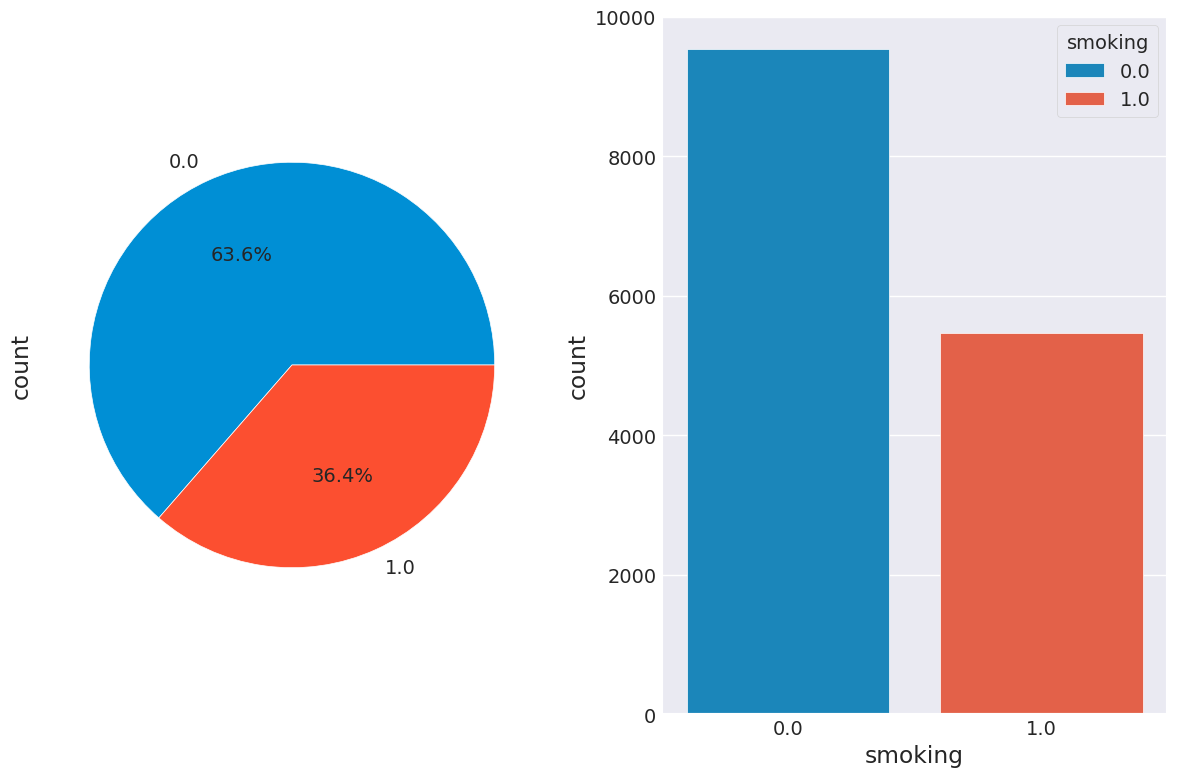

In [19]:
plt.subplot(121)
df['smoking'].value_counts().plot.pie(autopct='%1.1f%%')

plt.subplot(122)
sns.countplot(df, x='smoking', hue='smoking')
plt.tight_layout()

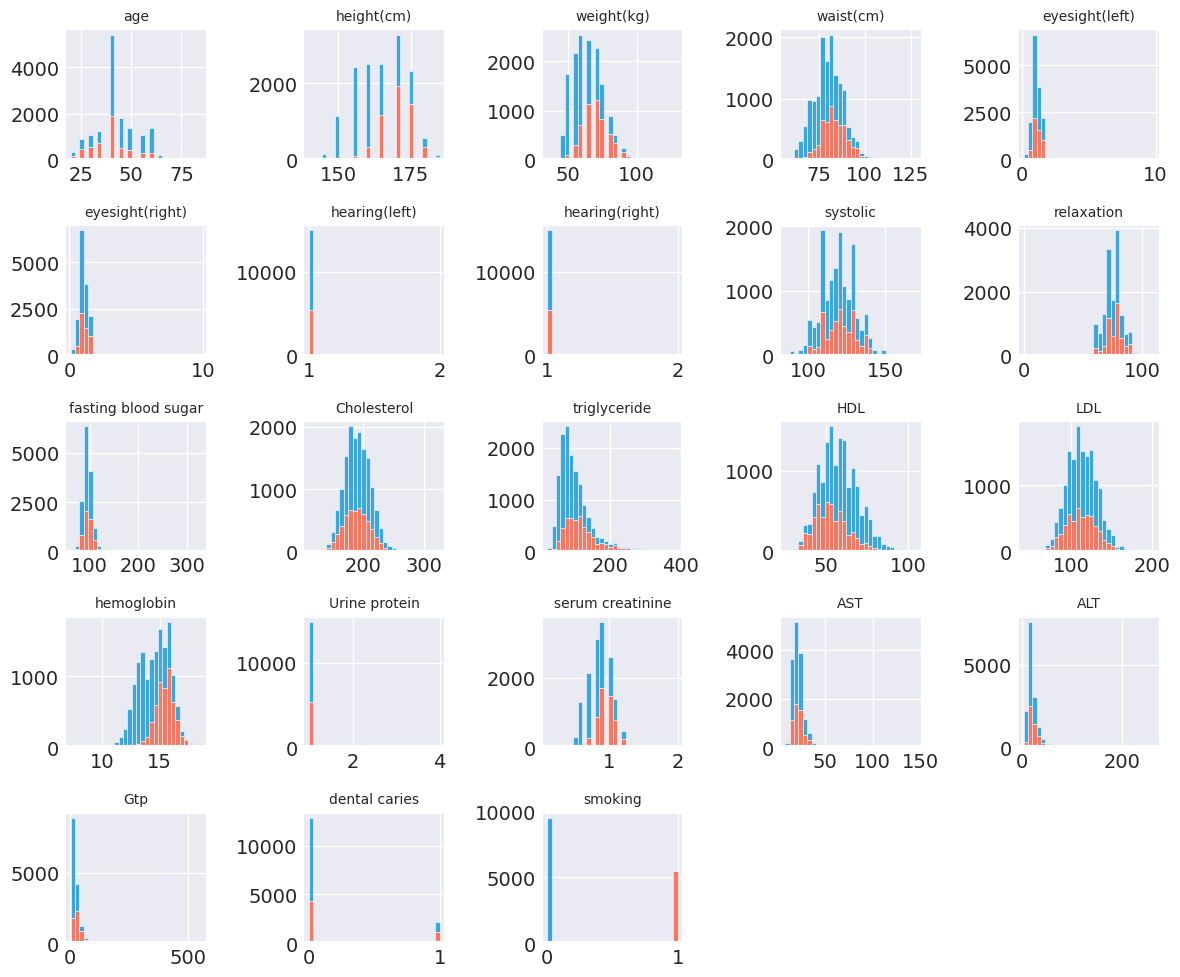

In [42]:
plt.figure(figsize=(12, 10))
for i, c in enumerate(df.columns):
    plt.subplot(5, 5, i + 1)
    sns.histplot(df, x=c, bins=30, hue='smoking', multiple='stack', legend=False)
    plt.title(c, fontsize=10)
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()

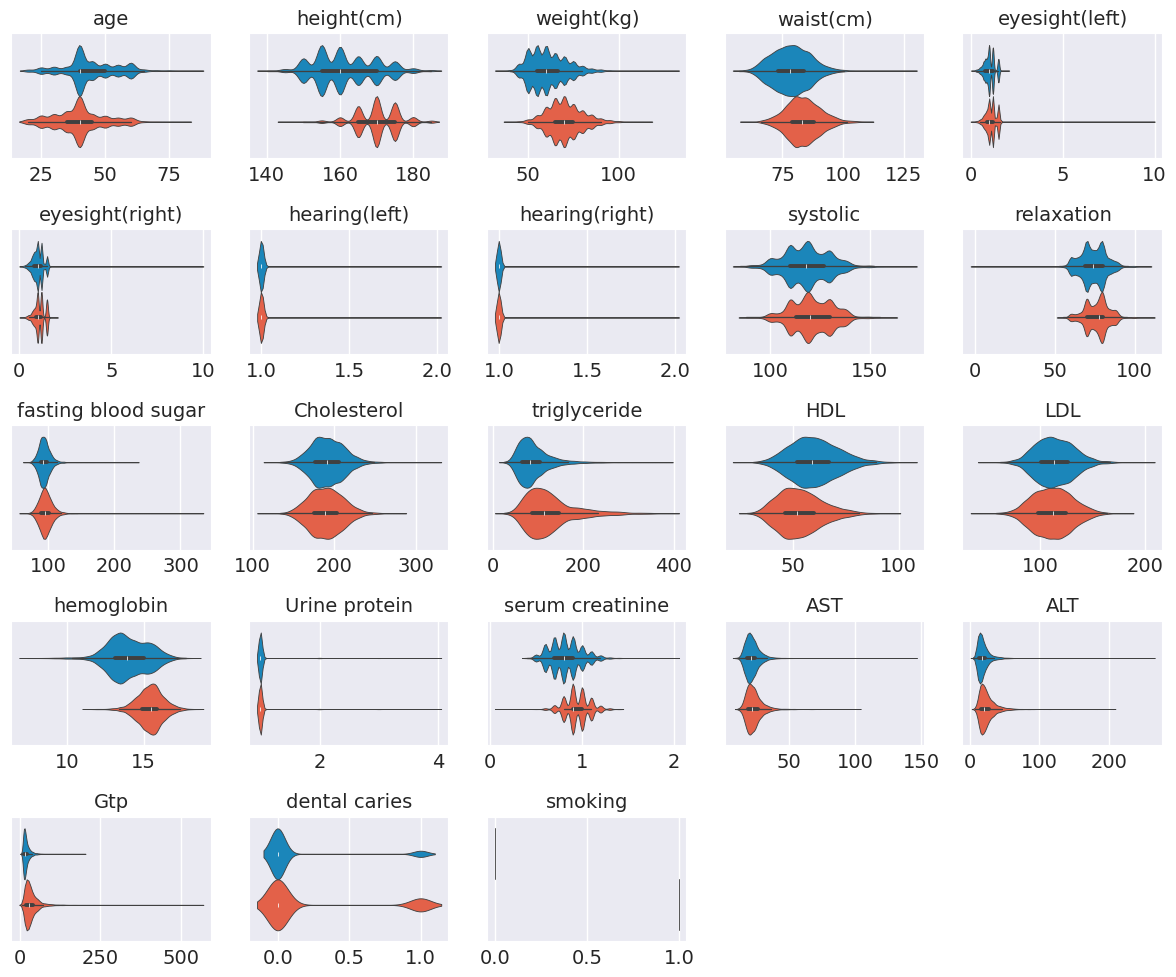

In [48]:
plt.figure(figsize=(12, 10))
for i, c in enumerate(df.columns):
    plt.subplot(5, 5, i + 1)
    sns.violinplot(df, x=c, hue='smoking', legend=False)
    plt.title(c, fontsize=14)
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()

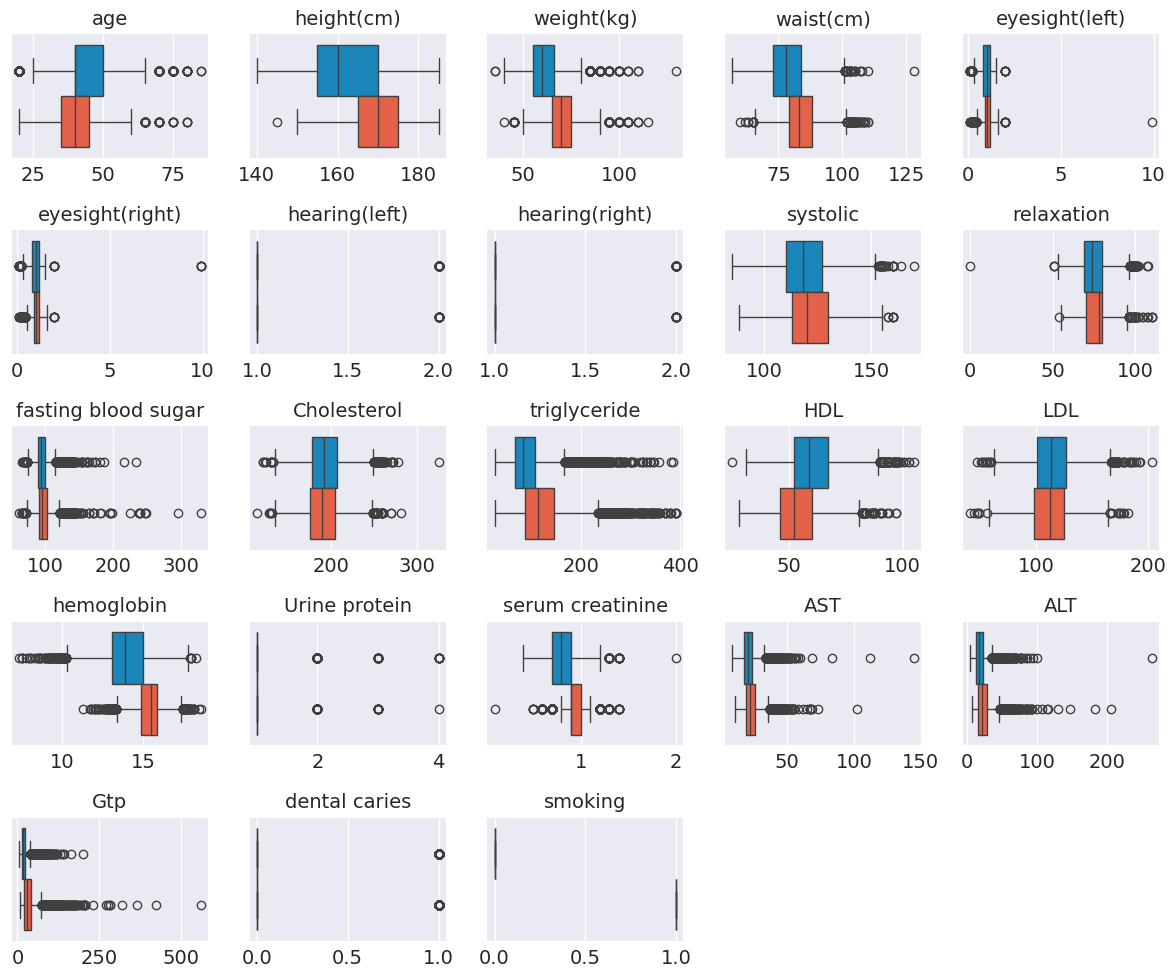

In [49]:
plt.figure(figsize=(12, 10))
for i, c in enumerate(df.columns):
    plt.subplot(5, 5, i + 1)
    sns.boxplot(df, x=c, hue='smoking', legend=False)
    plt.title(c, fontsize=14)
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()

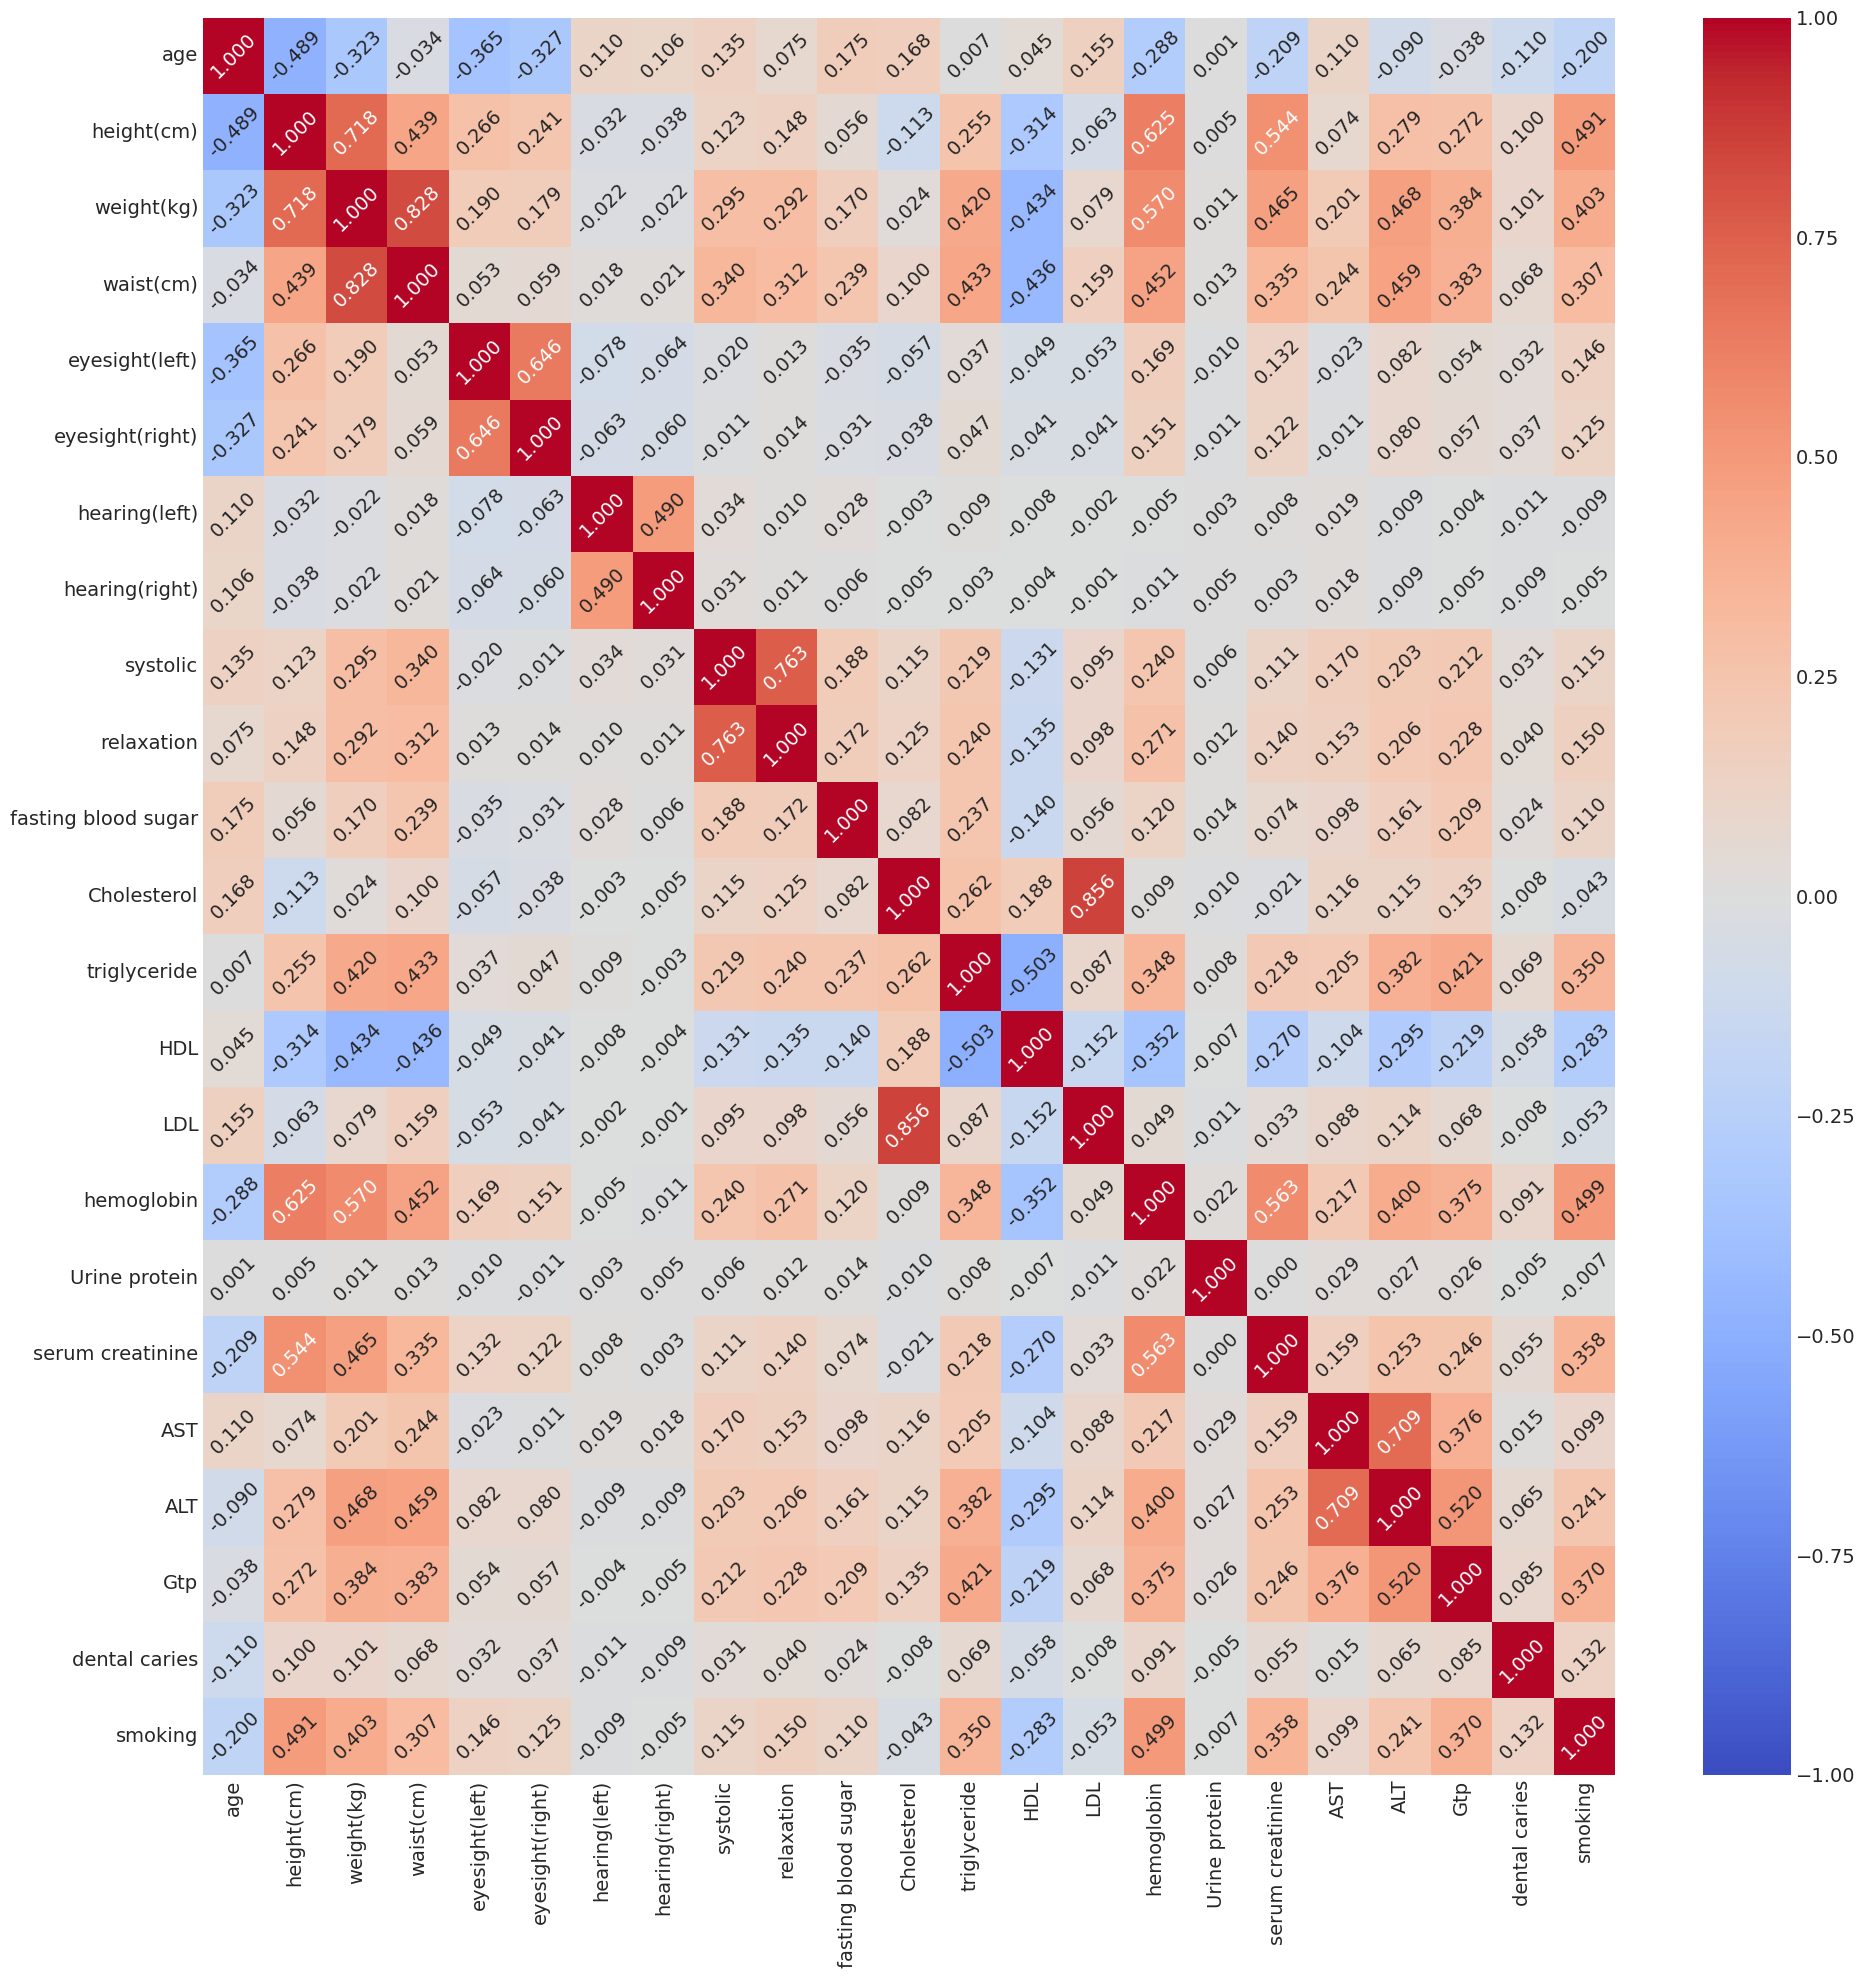

In [61]:
plt.figure(figsize=(20, 20))
sns.heatmap(
    df.corr(),
    annot=True,
    annot_kws={'rotation': 45},
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    cbar=True,
    fmt='.3f'
)
plt.tight_layout()

In [63]:
abs(df.corr()['smoking']).sort_values(ascending=False)

smoking                1.000000
hemoglobin             0.499494
height(cm)             0.491010
weight(kg)             0.402612
Gtp                    0.369674
serum creatinine       0.358102
triglyceride           0.349516
waist(cm)              0.306578
HDL                    0.282767
ALT                    0.241052
age                    0.199705
relaxation             0.150345
eyesight(left)         0.145737
dental caries          0.131943
eyesight(right)        0.124910
systolic               0.114520
fasting blood sugar    0.109900
AST                    0.098554
LDL                    0.053002
Cholesterol            0.042672
hearing(left)          0.009104
Urine protein          0.007193
hearing(right)         0.004881
Name: smoking, dtype: float64

## 4. Data Preprocessing

In [80]:
x = df.drop(columns=['smoking', 'hearing(right)', 'Urine protein', 'hearing(left)', 'Cholesterol', 'LDL', 'AST'])
y = df['smoking']

In [81]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

In [82]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [83]:
x_train.shape

(12000, 16)

## 5. Model Training

In [84]:
models = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'BernoulliNB': BernoulliNB(),
    'LogisticRegression': LogisticRegression(),
    'ExtraTreesClassifier': ExtraTreesClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(n_neighbors=5),
    'SVC': SVC(),
    'XGBClassifier': xgb.XGBClassifier(),
    'LightGBMClassifier': lgb.LGBMClassifier(verbose=-1)
}

def evaluate(x_train, y_train, x_test, y_test):
    results = []

    for i, (model_name, model) in enumerate(tqdm(models.items())):
        if 'random_state' in model.get_params():
            model.set_params(random_state=42)

        print(f'Training {model_name}...')
        y_pred = model.fit(x_train, y_train).predict(x_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='macro')
        recall = recall_score(y_test, y_pred, average='macro')
        f1 = f1_score(y_test, y_pred, average='macro')

        plt.subplot(3, 5, i+1)
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(model_name, fontsize=12)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()

        results.append({
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1
        })
        
    plt.suptitle('Confusion Matrices of All Models')
    plt.tight_layout()
    
    report = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
    report.reset_index(drop=True, inplace=True)
    return report

  0%|          | 0/12 [00:00<?, ?it/s]

Training GaussianNB...
Training MultinomialNB...
Training BernoulliNB...
Training LogisticRegression...
Training ExtraTreesClassifier...
Training DecisionTreeClassifier...
Training RandomForestClassifier...
Training GradientBoostingClassifier...
Training KNeighborsClassifier...
Training SVC...
Training XGBClassifier...
Training LightGBMClassifier...


,Model,Accuracy,Precision,Recall,F1 Score
0,LightGBMClassifier,0.797333,0.782630,0.789454,0.785522
1,SVC,0.792333,0.779093,0.792135,0.783161
2,GradientBoostingClassifier,0.792000,0.777801,0.788359,0.781622
3,RandomForestClassifier,0.786333,0.771109,0.777573,0.773844
4,ExtraTreesClassifier,0.785333,0.770918,0.781214,0.774622
5,XGBClassifier,0.782333,0.766857,0.772732,0.769380
6,LogisticRegression,0.764667,0.747806,0.748531,0.748162
7,KNeighborsClassifier,0.751333,0.733918,0.737199,0.735408
8,GaussianNB,0.749667,0.735893,0.747517,0.739054
9,DecisionTreeClassifier,0.731667,0.712358,0.711963,0.712159


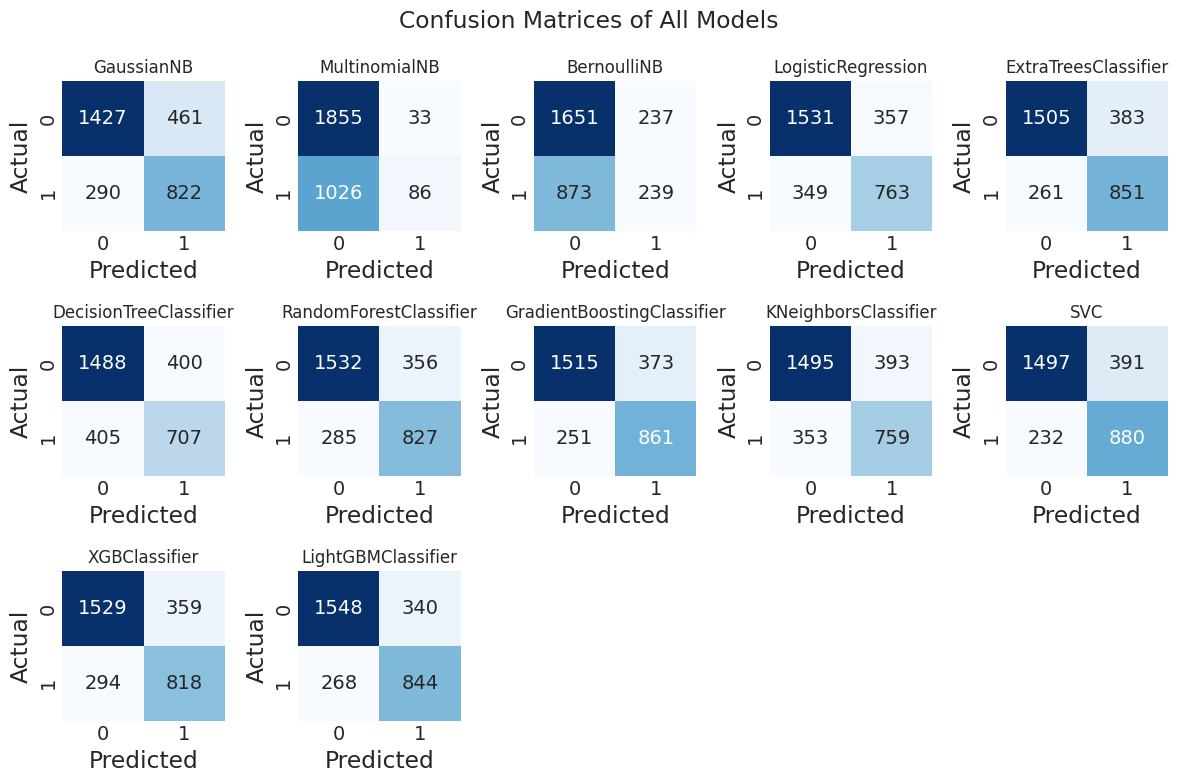

In [85]:
evaluate(x_train, y_train, x_test, y_test)

## 6. Building a Pipeline, Save the model, Make Submission

In [92]:
preprocessor = ColumnTransformer([
    ('scaler', MinMaxScaler(), x.columns)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMClassifier(verbose=-1, random_state=42))
])
pipeline.fit(x, y)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [93]:
pipeline.score(x, y)

0.8684

In [94]:
y_pred = pipeline.predict(x)
confusion_matrix(y, y_pred)

array([[8350, 1190],
       [ 784, 4676]])

In [95]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.88      0.89      9540
         1.0       0.80      0.86      0.83      5460

    accuracy                           0.87     15000
   macro avg       0.86      0.87      0.86     15000
weighted avg       0.87      0.87      0.87     15000



In [96]:
joblib.dump(pipeline, 'smoker_status_pipeline.pkl')

['smoker_status_pipeline.pkl']

In [97]:
test = pd.read_csv('test.csv', index_col='id')
predictions = pipeline.predict(test)
submission = pd.DataFrame({'id': test.index, 'smoking': predictions})
submission.head()

,id,smoking
0,15000,0.0
1,15001,0.0
2,15002,0.0
3,15003,1.0
4,15004,0.0


In [98]:
submission.to_csv('submission.csv', index=False)

## 7. Conclusion
We built a machine learning pipeline to predict the smoker status using bio-signals. We used the `LightGBM` model as the best model. We saved the pipeline for future use and used it to generate predictions for the test set and made a submission to the competition.

In [99]:
dict(x.dtypes)

{'age': dtype('float64'),
 'height(cm)': dtype('float64'),
 'weight(kg)': dtype('float64'),
 'waist(cm)': dtype('float64'),
 'eyesight(left)': dtype('float64'),
 'eyesight(right)': dtype('float64'),
 'systolic': dtype('float64'),
 'relaxation': dtype('float64'),
 'fasting blood sugar': dtype('float64'),
 'triglyceride': dtype('float64'),
 'HDL': dtype('float64'),
 'hemoglobin': dtype('float64'),
 'serum creatinine': dtype('float64'),
 'ALT': dtype('float64'),
 'Gtp': dtype('float64'),
 'dental caries': dtype('float64')}